In [210]:
%%capture --no-display
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn import preprocessing
import matplotlib.pyplot as plt
#-----------------------------------------------------##
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.kernel_ridge import KernelRidge
from sklearn import ensemble
from scipy import stats 
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV
from scipy.stats import kurtosis
from scipy.stats import skew
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import *
from sklearn.preprocessing import MinMaxScaler

In [211]:
dataset = pd.read_csv('./battery_ml.csv')
dataset.head()

,Unnamed: 0,dq_min,dq_mean,dq_variance,dq_skewness,dq_kurtosis,slope_100_2,intercept_100_2,discharge_capacity_2,discharge_capacity_100,...,slope_100_91,intercept_100_91,ave_chg_time_5_1,max_temp_100_2,min_temp_100_2,Integral_temp_100_2,integral_resistance_2,minimum_IR,difference_IR_100_2,cycle_life
0,0,-0.008460,-0.002873,0.000010,-0.532058,-1.348312,-0.000214,1.091381,1.070689,1.075913,...,0.000046,1.071447,13.374894,31.632496,31.266918,18.742036,0.016742,0.0,-0.000075,1852
1,1,-0.011004,-0.004100,0.000010,-0.429375,-1.029116,0.000007,1.080926,1.075301,1.080630,...,-0.000037,1.084382,13.409150,31.376623,31.076239,19.743747,0.017039,0.0,-0.000042,2160
2,2,-0.017216,-0.004487,0.000018,-1.080194,0.348637,0.000011,1.084805,1.079922,1.084940,...,-0.000040,1.088961,13.358242,31.447081,31.146742,19.985985,0.016868,0.0,-0.000014,2237
3,3,-0.018961,-0.007456,0.000036,-0.439050,-1.095416,0.000018,1.084030,1.079723,1.084750,...,-0.000002,1.084960,12.025140,29.982986,29.857000,18.640968,0.016370,0.0,0.000039,1434
4,4,-0.013958,-0.005750,0.000023,-0.362548,-1.333831,0.000020,1.081825,1.078417,1.082646,...,-0.000034,1.085988,12.041851,31.433310,31.181360,21.154489,0.016787,0.0,-0.000053,1709


In [212]:
dataset["cycle_life"]


0      1852
1      2160
2      2237
3      1434
4      1709
       ... 
119    1156
120     796
121     786
122     940
123    1801
Name: cycle_life, Length: 124, dtype: int64

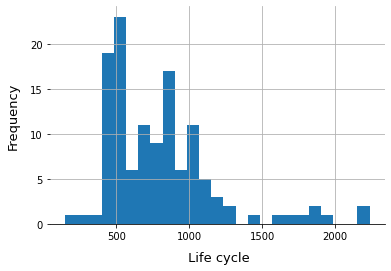

In [213]:
ax=dataset.hist(column='cycle_life',bins=25)
ax = ax[0] 
for x in ax:
    x.set_title("")
    x.set_xlabel(" Life cycle", labelpad=10, size=13)
    x.set_ylabel("Frequency", labelpad=10, size=13)

    x.spines['right'].set_visible(False)
    x.spines['top'].set_visible(False)
    x.spines['left'].set_visible(False)

In [214]:
import seaborn as sns

<AxesSubplot:xlabel='cycle_life'>

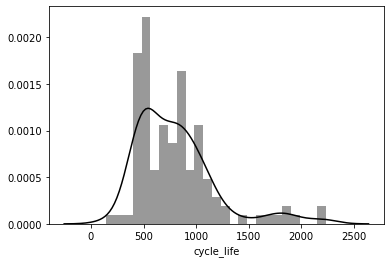

In [215]:
sns.distplot(dataset['cycle_life'],bins=25,kde=True,color='k')

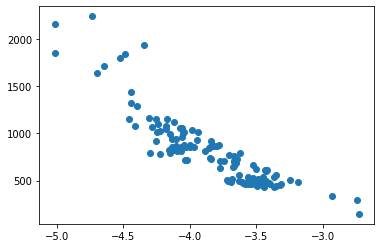

In [296]:
#dq_variance
plt.scatter(np.log10(dataset['dq_variance']),dataset['cycle_life'])


In [300]:
np.corrcoef(np.log10(dataset['dq_variance']),dataset['cycle_life'])

array([[ 1.        , -0.88974274],
       [-0.88974274,  1.        ]])

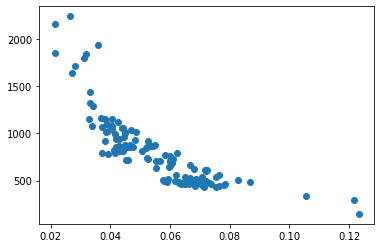

In [297]:
plt.scatter(np.cbrt(dataset['dq_variance']),dataset['cycle_life'])

In [298]:
np.corrcoef(np.cbrt(dataset['dq_variance']),dataset['cycle_life'])

array([[ 1.        , -0.80846817],
       [-0.80846817,  1.        ]])

In [217]:
#plt.scatter(np.log(dataset['dq_variance']),np.log10(dataset['cycle_life']))

In [218]:
#plt.scatter(((dataset['dq_variance']-np.mean(dataset['dq_variance'])/np.std(dataset['dq_variance']))),np.log10(dataset['cycle_life']))

In [219]:
print("*********** Original data*******************")
print(dataset['cycle_life'].describe())
print("skew : ",skew(dataset['cycle_life']))
print("kurt : ",kurtosis(dataset['cycle_life']))

*********** Original data*******************
count     124.000000
mean      801.637097
std       379.717082
min       148.000000
25%       498.750000
50%       736.500000
75%       946.500000
max      2237.000000
Name: cycle_life, dtype: float64
skew :  1.5722118774617826
kurt :  2.9001076537372352


In [220]:
#Selecting Features and Target,  X1=features, Y1=Target
X1=dataset.drop(["cycle_life",'Unnamed: 0'],axis=1)

In [221]:
X1

,dq_min,dq_mean,dq_variance,dq_skewness,dq_kurtosis,slope_100_2,intercept_100_2,discharge_capacity_2,discharge_capacity_100,diff_QD_n_2,slope_100_91,intercept_100_91,ave_chg_time_5_1,max_temp_100_2,min_temp_100_2,Integral_temp_100_2,integral_resistance_2,minimum_IR,difference_IR_100_2
0,-0.008460,-0.002873,0.000010,-0.532058,-1.348312,-2.137460e-04,1.091381,1.070689,1.075913,0.468365,0.000046,1.071447,13.374894,31.632496,31.266918,18.742036,0.016742,0.000000,-0.000075
1,-0.011004,-0.004100,0.000010,-0.429375,-1.029116,6.676023e-06,1.080926,1.075301,1.080630,0.009288,-0.000037,1.084382,13.409150,31.376623,31.076239,19.743747,0.017039,0.000000,-0.000042
2,-0.017216,-0.004487,0.000018,-1.080194,0.348637,1.149798e-05,1.084805,1.079922,1.084940,0.008131,-0.000040,1.088961,13.358242,31.447081,31.146742,19.985985,0.016868,0.000000,-0.000014
3,-0.018961,-0.007456,0.000036,-0.439050,-1.095416,1.846790e-05,1.084030,1.079723,1.084750,0.006530,-0.000002,1.084960,12.025140,29.982986,29.857000,18.640968,0.016370,0.000000,0.000039
4,-0.013958,-0.005750,0.000023,-0.362548,-1.333831,2.046078e-05,1.081825,1.078417,1.082646,0.005900,-0.000034,1.085988,12.041851,31.433310,31.181360,21.154489,0.016787,0.000000,-0.000053
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,-0.017458,-0.006428,0.000035,-0.292539,-1.003013,-5.631454e-06,1.050886,1.047404,1.049504,0.004107,-0.000005,1.050216,10.043833,34.218964,33.899652,51.489886,0.015741,0.015481,-0.000155
120,-0.022054,-0.009079,0.000051,-0.315431,-1.138513,-6.625013e-06,1.063355,1.059324,1.061757,0.004510,-0.000042,1.066049,10.043563,33.911189,32.981926,66.841951,0.015562,0.014996,-0.000234
121,-0.024193,-0.009748,0.000060,-0.357134,-1.063130,1.066398e-05,1.053846,1.050522,1.054153,0.004362,-0.000057,1.059706,10.042974,33.621746,32.648149,72.070386,0.018542,0.017007,-0.000173
122,-0.025985,-0.011231,0.000074,-0.244616,-1.238396,5.494642e-06,1.073051,1.069720,1.072928,0.004185,-0.000028,1.075614,10.043436,33.111576,32.626095,64.641417,0.015723,0.015505,-0.000106


In [222]:
X1=X1[['dq_min','dq_variance','slope_100_2','intercept_100_2',
    'discharge_capacity_2','ave_chg_time_5_1','Integral_temp_100_2',
   'minimum_IR','difference_IR_100_2']]

In [223]:
X1

,dq_min,dq_variance,slope_100_2,intercept_100_2,discharge_capacity_2,ave_chg_time_5_1,Integral_temp_100_2,minimum_IR,difference_IR_100_2
0,-0.008460,0.000010,-2.137460e-04,1.091381,1.070689,13.374894,18.742036,0.000000,-0.000075
1,-0.011004,0.000010,6.676023e-06,1.080926,1.075301,13.409150,19.743747,0.000000,-0.000042
2,-0.017216,0.000018,1.149798e-05,1.084805,1.079922,13.358242,19.985985,0.000000,-0.000014
3,-0.018961,0.000036,1.846790e-05,1.084030,1.079723,12.025140,18.640968,0.000000,0.000039
4,-0.013958,0.000023,2.046078e-05,1.081825,1.078417,12.041851,21.154489,0.000000,-0.000053
...,...,...,...,...,...,...,...,...,...
119,-0.017458,0.000035,-5.631454e-06,1.050886,1.047404,10.043833,51.489886,0.015481,-0.000155
120,-0.022054,0.000051,-6.625013e-06,1.063355,1.059324,10.043563,66.841951,0.014996,-0.000234
121,-0.024193,0.000060,1.066398e-05,1.053846,1.050522,10.042974,72.070386,0.017007,-0.000173
122,-0.025985,0.000074,5.494642e-06,1.073051,1.069720,10.043436,64.641417,0.015505,-0.000106


In [224]:
export=pd.concat([X1,dataset["cycle_life"]],axis=1)

In [225]:
export.to_csv('sisso.csv',sep=' ')

In [226]:
X1['dq_variance']=np.log10(X1['dq_variance'])

C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [227]:
#X1 = preprocessing.scale(X1)

In [228]:
Y1=dataset["cycle_life"]

In [229]:
#Y1=Y.apply(lambda x: np.sqrt(x))
#Y1=Y.apply(lambda x: x**(1/3))
#Y1=Y.apply(lambda x: np.log(x))
#Y1=Y.apply(lambda x: x**(-0.375))
#Y1=Y
#Y1.hist(bins=20)
#print("*********** Original data*******************")
#print(Y1.describe())
#print("skew : ",skew(Y1))
#print("kurt : ",kurtosis(Y1))

In [230]:
X_train, X_test, Y_train, Y_test = train_test_split(X1[0:82], Y1[0:82],
                                                    test_size = 0.4, random_state=1000)

In [231]:
#X_train=X1[0:40]
#Y_train=Y1[0:40]

In [232]:
#X_test=X1[41:83]
#Y_test=Y1[41:83]

In [233]:
X_val=X1[84:123]
Y_val=Y1[84:123]

# Regression with ElasticNet

In [234]:
model=ElasticNet()

In [235]:
model.fit(X_train,Y_train)

ElasticNet(alpha=1.0, copy_X=True, fit_intercept=True, l1_ratio=0.5,
           max_iter=1000, normalize=False, positive=False, precompute=False,
           random_state=None, selection='cyclic', tol=0.0001, warm_start=False)

In [236]:
##### model evaluation for training set
y_train_predict = model.predict(X_train)
rmse = (np.sqrt(mean_squared_error(Y_train, y_train_predict)))
r2 = r2_score(Y_train, y_train_predict)
print("The model performance for training set")
print("--------------------------------------")
print('RMSE is {}'.format(rmse))
print('R2 score is {}'.format(r2))

The model performance for training set
--------------------------------------
RMSE is 190.9254117682176
R2 score is 0.6854173680537767


In [237]:
# model evaluation for test set
y_test_predict = model.predict(X_test)
rmse_test = (np.sqrt(mean_squared_error(Y_test, y_test_predict)))
r2_test = r2_score(Y_test, y_test_predict)
print("The model performance for testing set")
print("--------------------------------------")
print('RMSE is {}'.format(rmse_test))
print('R2 score is {}'.format(r2_test))

The model performance for testing set
--------------------------------------
RMSE is 243.5131897989658
R2 score is 0.6165777800090522


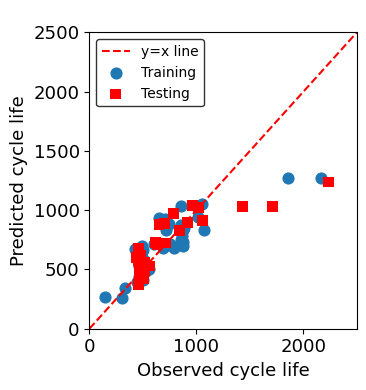

In [238]:
#### define your data plot here       
plt.figure(figsize=(4,4),dpi=100)
plt.title(' ', fontsize=13) 
#### define your data plot here       
plt.xlim((0,2500))
# plt.xticks(np.linspace(0,2,0.5,endpoint=True))
plt.ylim((0,2500))
# plt.yticks(np.linspace(0,2,0.5,endpoint=True))
plt.tick_params(axis='both', which='major', labelsize=13)
plt.scatter(Y_train, y_train_predict, label='Training',
            s=60,marker='o')
plt.scatter(Y_test,y_test_predict, label='Testing',
            facecolors='red',alpha=1, edgecolors='none',s=60, marker='s')
plt.xlabel("Observed cycle life",fontsize=13)
plt.ylabel("Predicted cycle life",fontsize=13)

#####fitting with a y=x line here (polynomial approach)
#p1 = np.polyfit(Y_train, y_train_predict,1)
plt.plot((0,2500),(0,2500), 'r-',linestyle='dashed',label='y=x line')
plt.tight_layout()
leg = plt.legend()
leg.get_frame().set_edgecolor('black')

In [239]:
# model evaluation for Validation set
y_val_predict = model.predict(X_val)
rmse_val = (np.sqrt(mean_squared_error(Y_val, y_val_predict)))
r2_val = r2_score(Y_val, y_val_predict)
print("The model performance for validation set")
print("--------------------------------------")
print('RMSE is {}'.format(rmse_val))
print('R2 score is {}'.format(r2_val))

The model performance for validation set
--------------------------------------
RMSE is 674.4035784382855
R2 score is -4.708007712554381


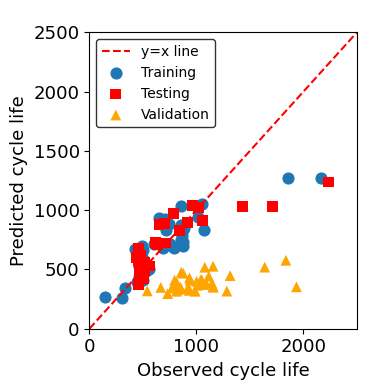

In [240]:
#### define your data plot here       
plt.figure(figsize=(4,4),dpi=100)
plt.title(' ', fontsize=13) 
#### define your data plot here       
plt.xlim((0,2500))
# plt.xticks(np.linspace(0,2,0.5,endpoint=True))
plt.ylim((0,2500))
# plt.yticks(np.linspace(0,2,0.5,endpoint=True))
plt.tick_params(axis='both', which='major', labelsize=13)
plt.scatter(Y_train, y_train_predict, label='Training',
            s=60,marker='o')
plt.scatter(Y_test,y_test_predict, label='Testing',
            facecolors='red',alpha=1, edgecolors='none',s=60, marker='s')
plt.scatter(Y_val, y_val_predict, label='Validation',
            facecolors='orange',alpha=1, edgecolors='none',s=60, marker='^')
plt.xlabel("Observed cycle life",fontsize=13)
plt.ylabel("Predicted cycle life",fontsize=13)

#####fitting with a y=x line here (polynomial approach)
#p1 = np.polyfit(Y_train, y_train_predict,1)
plt.plot((0,2500),(0,2500), 'r-',linestyle='dashed',label='y=x line')
plt.tight_layout()
leg = plt.legend()
leg.get_frame().set_edgecolor('black')

### Optimization of Hyperparameters, e.g., alpha, and l1_ratio
$ 1/(2*n_{samples}) * ||y - Xw||^2
+ \alpha * L1_{ratio} * ||w||
+ 0.5 * \alpha * (1 - L1_{ratio}) * ||w||^2 $
1. Here I am using GridSearchCV/ElasticNetCV tools of sklearn

In [241]:
from sklearn.linear_model import ElasticNetCV

In [242]:
alpha_x=np.linspace(0.01,1,100)
l1_ratio_x=np.linspace(0,0.5,1000)

In [243]:
regr = ElasticNetCV(n_alphas=100,alphas=alpha_x,eps=0.005,l1_ratio=l1_ratio_x,cv=5, random_state=11110,max_iter=5000)
regr.fit(X_train,Y_train)

C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: UserWarning: Coordinate descent with alpha=0 may lead to unexpected results and is discouraged.
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1271263.6050211976, tolerance: 528.2524974358975
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: UserWarning: Coordinate descent with alpha=0 may lead to unexpected results and is discouraged.
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: ConvergenceWarning: Objective did not converge. You might want to increase the numb

C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1019333.6021453154, tolerance: 528.2524974358975
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: UserWarning: Coordinate descent with alpha=0 may lead to unexpected results and is discouraged.
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1012327.2239857302, tolerance: 528.2524974358975
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: UserWarning: Coo

C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: UserWarning: Coordinate descent with alpha=0 may lead to unexpected results and is discouraged.
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 344330.708002218, tolerance: 528.2524974358975
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: UserWarning: Coordinate descent with alpha=0 may lead to unexpected results and is discouraged.
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: ConvergenceWarning: Objective did not converge. You might want to increase the number

C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1147265.72824302, tolerance: 541.6349230769231
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: UserWarning: Coordinate descent with alpha=0 may lead to unexpected results and is discouraged.
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1140696.3808371443, tolerance: 541.6349230769231
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: UserWarning: Coord

C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 576039.4426618449, tolerance: 541.6349230769231
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: UserWarning: Coordinate descent with alpha=0 may lead to unexpected results and is discouraged.
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 553037.4363165267, tolerance: 541.6349230769231
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: UserWarning: Coord

...

C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 649515.5398656249, tolerance: 514.5795743589745
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: UserWarning: Coordinate descent with alpha=0 may lead to unexpected results and is discouraged.
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 627854.8368276847, tolerance: 514.5795743589745
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: UserWarning: Coord

C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1140594.8651396725, tolerance: 498.3715230769231
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: UserWarning: Coordinate descent with alpha=0 may lead to unexpected results and is discouraged.
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1133840.6989847245, tolerance: 498.3715230769231
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: UserWarning: Coo

C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 633350.0204373576, tolerance: 498.3715230769231
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: UserWarning: Coordinate descent with alpha=0 may lead to unexpected results and is discouraged.
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 611499.3009520364, tolerance: 498.3715230769231
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: UserWarning: Coord

C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 347980.8099404848, tolerance: 165.04557750000004
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: UserWarning: Coordinate descent with alpha=0 may lead to unexpected results and is discouraged.
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 347447.55218235956, tolerance: 165.04557750000004
  tol, rng, random, positive)
C:\Users\sanna69\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:472: UserWarning: Co

KeyboardInterrupt: 

In [ ]:
regr

In [ ]:
print(regr.alpha_)

In [77]:
print(regr.l1_ratio_)

0.5


In [ ]:
regr.intercept_

In [ ]:
regr.n_iter_

In [ ]:
regr.dual_gap_

In [250]:
#model=Lasso(alpha=2.40)
model=ElasticNet(alpha=0.00001,l1_ratio=0.91,fit_intercept=True,tol=0.00001,max_iter=5000000,random_state=1)


In [251]:
model.fit(X_train,Y_train)

ElasticNet(alpha=1e-05, copy_X=True, fit_intercept=True, l1_ratio=0.91,
           max_iter=5000000, normalize=False, positive=False, precompute=False,
           random_state=1, selection='cyclic', tol=1e-05, warm_start=False)

In [252]:
#### model evaluation for training set
y_train_predict = model.predict(X_train)
rmse = (np.sqrt(mean_squared_error(Y_train, y_train_predict)))
r2 = r2_score(Y_train, y_train_predict)
print("The model performance for training set")
print("--------------------------------------")
print('RMSE is {}'.format(rmse))
print('R2 score is {}'.format(r2))


The model performance for training set
--------------------------------------
RMSE is 78.53879839080203
R2 score is 0.9467676333630834


In [253]:
# model evaluation for test set
y_test_predict = model.predict(X_test)
rmse_test = (np.sqrt(mean_squared_error(Y_test, y_test_predict)))
r2_test = r2_score(Y_test, y_test_predict)
print("The model performance for testing set")
print("--------------------------------------")
print('RMSE is {}'.format(rmse_test))
print('R2 score is {}'.format(r2_test))

The model performance for testing set
--------------------------------------
RMSE is 128.84409579928015
R2 score is 0.8926600614392144


In [254]:
X_val=X1[84:123]
Y_val=Y1[84:123]

In [255]:
# model evaluation for Validation set
y_val_predict = model.predict(X_val)
rmse_val = (np.sqrt(mean_squared_error(Y_val, y_val_predict)))
r2_val = r2_score(Y_val, y_val_predict)
print("The model performance for validation set")
print("--------------------------------------")
print('RMSE is {}'.format(rmse_val))
print('R2 score is {}'.format(r2_val))

The model performance for validation set
--------------------------------------
RMSE is 222.7344324865233
R2 score is 0.37738505843275416


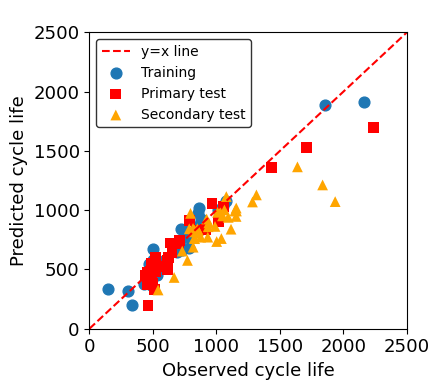

In [257]:
#### define your data plot here       
plt.figure(figsize=(4.5,4),dpi=100)
plt.title(' ', fontsize=13) 
#### define your data plot here       
plt.xlim((0,2500))
plt.xticks(np.linspace(0,2500,6,endpoint=True))
plt.ylim((0,2500))
plt.yticks(np.linspace(0,2500,6,endpoint=True))
plt.tick_params(axis='both', which='major', labelsize=13)
plt.scatter(Y_train, y_train_predict, label='Training',
            s=60,marker='o')
plt.scatter(Y_test,y_test_predict, label='Primary test',
            facecolors='red',alpha=1, edgecolors='none',s=60, marker='s')
plt.scatter(Y_val, y_val_predict, label='Secondary test',
            facecolors='orange',alpha=1, edgecolors='none',s=60, marker='^')
plt.xlabel("Observed cycle life",fontsize=13)
plt.ylabel("Predicted cycle life",fontsize=13)

#####fitting with a y=x line here (polynomial approach)
#p1 = np.polyfit(Y_train, y_train_predict,1)
plt.plot((0,2500),(0,2500), 'r-',linestyle='dashed',label='y=x line')
leg = plt.legend()
leg.get_frame().set_edgecolor('black')
plt.tight_layout()

In [249]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from numpy import absolute

In [70]:
first_bit= np.log10(dataset["discharge_capacity_2"])/(dataset["dq_variance"])**(1/3)

In [71]:
second_bit=(dataset["dq_variance"]**(1/3))*(dataset["dq_variance"]/dataset["dq_variance"])

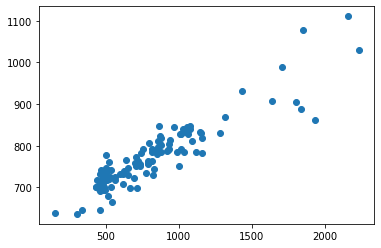

In [75]:
plt.scatter(dataset["cycle_life"], (0.3786262607E+03*first_bit)+(-0.6281856557E+02*second_bit)+0.5522646811E+03)
#plt.xlim(0,2000)
#plt.ylim(0,2000)

In [258]:
df_new= pd. DataFrame({'first_f':first_bit,
                     'second_f':second_bit,
                      })

In [259]:
Y2=dataset["cycle_life"]

In [260]:
df_new.shape

(124, 2)

In [261]:
X_train, X_test, Y_train, Y_test = train_test_split(df_new[0:82], Y2[0:82],
                                                    test_size = 0.5, random_state=1000)

In [262]:
X_val=df_new[84:123]
#X_val=X1[84:123]
Y_val=Y2[84:123]

In [263]:
model=ElasticNet(alpha=0.00001,l1_ratio=0.91,fit_intercept=True,tol=0.00001,max_iter=5000000,random_state=1)
model.fit(X_train,Y_train)

ElasticNet(alpha=1e-05, copy_X=True, fit_intercept=True, l1_ratio=0.91,
           max_iter=5000000, normalize=False, positive=False, precompute=False,
           random_state=1, selection='cyclic', tol=1e-05, warm_start=False)

In [264]:
#### model evaluation for training set
y_train_predict = model.predict(X_train)
rmse = (np.sqrt(mean_squared_error(Y_train, y_train_predict)))
r2 = r2_score(Y_train, y_train_predict)
print("The model performance for training set")
print("--------------------------------------")
print('RMSE is {}'.format(rmse))
print('R2 score is {}'.format(r2))


The model performance for training set
--------------------------------------
RMSE is 69.86534636432081
R2 score is 0.9624257681492767


In [265]:
# model evaluation for test set
y_test_predict = model.predict(X_test)
rmse_test = (np.sqrt(mean_squared_error(Y_test, y_test_predict)))
r2_test = r2_score(Y_test, y_test_predict)
print("The model performance for testing set")
print("--------------------------------------")
print('RMSE is {}'.format(rmse_test))
print('R2 score is {}'.format(r2_test))

The model performance for testing set
--------------------------------------
RMSE is 126.03396212343371
R2 score is 0.8811943482690698


In [266]:
# model evaluation for Validation set
y_val_predict = model.predict(X_val)
rmse_val = (np.sqrt(mean_squared_error(Y_val, y_val_predict)))
r2_val = r2_score(Y_val, y_val_predict)
print("The model performance for validation set")
print("--------------------------------------")
print('RMSE is {}'.format(rmse_val))
print('R2 score is {}'.format(r2_val))

The model performance for validation set
--------------------------------------
RMSE is 261.8021024064567
R2 score is 0.1398165570382388


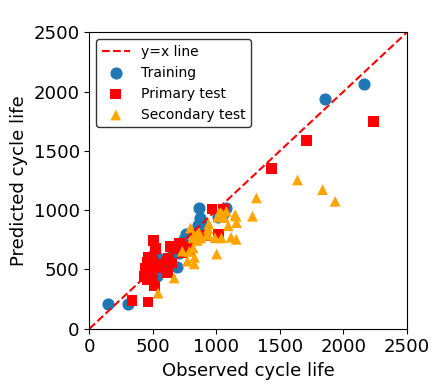

In [267]:
#### define your data plot here       
plt.figure(figsize=(4.5,4),dpi=100)
plt.title(' ', fontsize=13) 
#### define your data plot here       
plt.xlim((0,2500))
plt.xticks(np.linspace(0,2500,6,endpoint=True))
plt.ylim((0,2500))
plt.yticks(np.linspace(0,2500,6,endpoint=True))
plt.tick_params(axis='both', which='major', labelsize=13)
plt.scatter(Y_train, y_train_predict, label='Training',
            s=60,marker='o')
plt.scatter(Y_test,y_test_predict, label='Primary test',
            facecolors='red',alpha=1, edgecolors='none',s=60, marker='s')
plt.scatter(Y_val, y_val_predict, label='Secondary test',
            facecolors='orange',alpha=1, edgecolors='none',s=60, marker='^')
plt.xlabel("Observed cycle life",fontsize=13)
plt.ylabel("Predicted cycle life",fontsize=13)

#####fitting with a y=x line here (polynomial approach)
#p1 = np.polyfit(Y_train, y_train_predict,1)
plt.plot((0,2500),(0,2500), 'r-',linestyle='dashed',label='y=x line')
leg = plt.legend()
leg.get_frame().set_edgecolor('black')
plt.tight_layout()

In [268]:
dataset["difference_IR_100_2"]

0     -0.000075
1     -0.000042
2     -0.000014
3      0.000039
4     -0.000053
         ...   
119   -0.000155
120   -0.000234
121   -0.000173
122   -0.000106
123   -0.000080
Name: difference_IR_100_2, Length: 124, dtype: float64

In [282]:
#4D Descriptor
onebit= (dataset["dq_min"]/dataset["dq_variance"])*np.log10(dataset["discharge_capacity_2"])
#onebit= (dataset["dq_min"]/np.log10(dataset["dq_variance"]))*np.log10(dataset["discharge_capacity_2"])

In [283]:
twobit=(dataset["dq_variance"]*dataset["slope_100_2"])/(dataset["dq_variance"]-dataset["slope_100_2"])
#twobit=(np.log10(dataset["dq_variance"])*dataset["slope_100_2"])/(np.log(dataset["dq_variance"])-dataset["slope_100_2"])

In [284]:
threebit=np.abs((dataset["ave_chg_time_5_1"]/dataset["difference_IR_100_2"])-(dataset["Integral_temp_100_2"]/dataset["difference_IR_100_2"]))

In [286]:
fourbit=(dataset["difference_IR_100_2"]/dataset["dq_variance"])/(dataset["dq_variance"]+dataset["slope_100_2"])
#fourbit=(dataset["difference_IR_100_2"]/(np.log10(dataset["dq_variance"])))/(np.log10(dataset["dq_variance"])+dataset["slope_100_2"])

In [287]:
dq_new=pd.DataFrame({'obe_bit':onebit,
                    'two_bit': twobit,
                   'three_bit':threebit,
                   'fourbit':fourbit})

In [288]:
X_train, X_test, Y_train, Y_test = train_test_split(dq_new[0:83], Y2[0:83],
                                                    test_size = 0.2, random_state=1000)

In [289]:
X_val=dq_new[84:123]
#X_val=X1[84:123]
Y_val=Y2[84:123]

In [290]:
model=ElasticNet(alpha=0.0001,l1_ratio=0.5,fit_intercept=True,tol=0.0001,max_iter=5000000,random_state=1)
from sklearn.linear_model import LinearRegression
#model=LinearRegression()
model.fit(X_train,Y_train)

ElasticNet(alpha=0.0001, copy_X=True, fit_intercept=True, l1_ratio=0.5,
           max_iter=5000000, normalize=False, positive=False, precompute=False,
           random_state=1, selection='cyclic', tol=0.0001, warm_start=False)

In [291]:
#### model evaluation for training set
y_train_predict = model.predict(X_train)
rmse = (np.sqrt(mean_squared_error(Y_train, y_train_predict)))
r2 = r2_score(Y_train, y_train_predict)
print("The model performance for training set")
print("--------------------------------------")
print('RMSE is {}'.format(rmse))
print('R2 score is {}'.format(r2))


The model performance for training set
--------------------------------------
RMSE is 84.34827238187135
R2 score is 0.9461475898661794


In [292]:
# model evaluation for test set
y_test_predict = model.predict(X_test)
rmse_test = (np.sqrt(mean_squared_error(Y_test, y_test_predict)))
r2_test = r2_score(Y_test, y_test_predict)
print("The model performance for testing set")
print("--------------------------------------")
print('RMSE is {}'.format(rmse_test))
print('R2 score is {}'.format(r2_test))

The model performance for testing set
--------------------------------------
RMSE is 111.61515054106677
R2 score is 0.9022134208838162


In [293]:
# model evaluation for Validation set
y_val_predict = model.predict(X_val)
rmse_val = (np.sqrt(mean_squared_error(Y_val, y_val_predict)))
r2_val = r2_score(Y_val, y_val_predict)
print("The model performance for validation set")
print("--------------------------------------")
print('RMSE is {}'.format(rmse_val))
print('R2 score is {}'.format(r2_val))

The model performance for validation set
--------------------------------------
RMSE is 331.22911733251186
R2 score is -0.37689820502582116


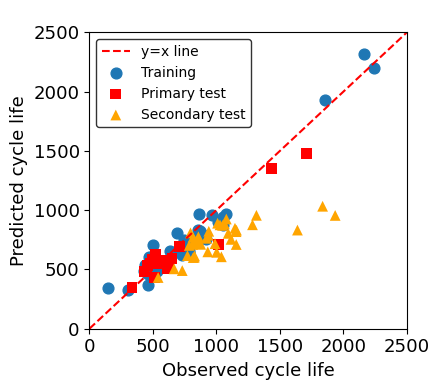

In [294]:
#### define your data plot here       
plt.figure(figsize=(4.5,4),dpi=100)
plt.title(' ', fontsize=13) 
#### define your data plot here       
plt.xlim((0,2500))
plt.xticks(np.linspace(0,2500,6,endpoint=True))
plt.ylim((0,2500))
plt.yticks(np.linspace(0,2500,6,endpoint=True))
plt.tick_params(axis='both', which='major', labelsize=13)
plt.scatter(Y_train, y_train_predict, label='Training',
            s=60,marker='o')
plt.scatter(Y_test,y_test_predict, label='Primary test',
            facecolors='red',alpha=1, edgecolors='none',s=60, marker='s')
plt.scatter(Y_val, y_val_predict, label='Secondary test',
            facecolors='orange',alpha=1, edgecolors='none',s=60, marker='^')
plt.xlabel("Observed cycle life",fontsize=13)
plt.ylabel("Predicted cycle life",fontsize=13)

#####fitting with a y=x line here (polynomial approach)
#p1 = np.polyfit(Y_train, y_train_predict,1)
plt.plot((0,2500),(0,2500), 'r-',linestyle='dashed',label='y=x line')
leg = plt.legend()
leg.get_frame().set_edgecolor('black')
plt.tight_layout()